# Selecting the relative evidence threshold for operational negatives

This notebook selects the `relative_threshold` that `predictive_heads_initial.yaml`
still marks `TODO`. It measures what the threshold buys — unannotated entries converted
into operational negatives — against what it costs — annotated entries whose own local
evidence falls below the same level, so that the rule contradicts a label known to be
true. The recommendation is the largest threshold whose contradiction rate stays inside
a stated tolerance.

It depends on `part_0_1`, which established the annotation prevalence and the spectral
background level any threshold must be read against, and it fixes the dilation radius at
the configured value; `part_0_3` examines that choice and the stability of the selected
threshold.

## Introduction

Six of the twelve grid cells in the campaign — the four `SignalMaskedBCELoss` cells and
the two `ThreeStateCrossEntropyLoss` cells — replace the "absent annotation means
negative" convention with an evidence rule. For pixel $i$ and ion $c$ it computes the
largest intensity in a window of $2\rho + 1$ bins around the ion's bin and compares it
against a threshold set by the pixel's own maximum:

$$
s_{ic} = \max_{b \in \mathcal{B}_c^{(\rho)}} x_{ib},
\qquad
\tau_i = \max\!\left(\alpha,\; \beta \max_b x_{ib}\right),
\qquad
S_{ic} =
\begin{cases}
P & y_{ic} = 1,\\
U & y_{ic} = 0 \text{ and } s_{ic} > \tau_i,\\
N & y_{ic} = 0 \text{ and } s_{ic} \le \tau_i.
\end{cases}
$$

With $\alpha = 0$, as every cell in this campaign configures, the rule collapses onto a
single scalar per entry — the *relative evidence*

$$
r_{ic} \;=\; \frac{s_{ic}}{\max_b x_{ib}} \in [0, 1],
\qquad
S_{ic} = N \iff y_{ic} = 0 \;\wedge\; r_{ic} \le \beta .
$$

Selecting $\beta$ is therefore choosing a cut point on the distribution of one measured
quantity, and every statement below is a statement about that distribution.

### Assumptions

- **Annotations are correct where present, incomplete where absent.** This is the
  premise the whole construction rests on. It licenses using annotated entries as a
  reference population for what a real ion looks like, and it forbids using unannotated
  entries as negatives without further evidence.
- **The contradiction rate is a validity bound, not an error rate.** An annotated entry
  below the threshold is never mislabelled by the rule — $P$ is assigned before the
  signal is consulted. It is used here as an estimate of how often the rule *would* be
  wrong on an entry of the same kind that happens to lack an annotation. This is an
  estimate on a biased sample: annotated entries are, by construction, ones METASPACE
  could detect, so the true error rate on unannotated entries is plausibly higher, not
  lower. The bound is therefore optimistic and is treated as such.
- **$\alpha = 0$ throughout.** The absolute floor is fixed at zero, as configured. Its
  alternative parameterization is examined in `part_0_3`.
- **Population and preprocessing** as in `part_0_1`: all 420 649 annotated pixels,
  0.55 Da binning over 200-900 m/z, TIC normalization, measured through the trainer's own
  preprocessing path.

### Notation

Extends `part_0_1`. Additionally:

- $r_{ic} \in [0, 1]$ — relative evidence, as above; $\beta$ — the relative threshold.
- $A = \{(i, c) : y_{ic} = 1, m_{ic} = 1\}$ — annotated entries;
  $\bar{A} = \{(i, c) : y_{ic} = 0, m_{ic} = 1\}$ — unannotated entries.
- $\mathrm{yield}(\beta) = \Pr(r \le \beta \mid \bar{A})$ — negative yield.
- $\mathrm{contra}(\beta) = \Pr(r \le \beta \mid A)$ — positive contradiction rate.
- $\mathrm{AUC}_c$ — the per-ion rank agreement between annotation and evidence, defined
  in its own section.

## Configuration

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper.analysis.autoencoder.evidence import EvidenceStatistics
from msi_autoencoder_wrapper.analysis.autoencoder.evidence import class_population_analysis as population
from msi_autoencoder_wrapper.analysis.autoencoder.evidence import threshold_analysis as thresholds
from msi_autoencoder_wrapper.analysis.autoencoder.evidence import views
from msi_autoencoder_wrapper.utils.logger import get_custom_logger
from msi_autoencoder_wrapper.visualization import resolve_theme

logger = get_custom_logger("evidence_threshold_selection")

2026-09-19 23:31:53,122 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.


2026-09-19 23:31:53,125 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 6 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.


In [2]:
from msi_autoencoder_wrapper.analysis.autoencoder.experiments import predictive_campaign as campaign

SETTINGS_PATH = Path("assets/experiments/autoencoder_architecture/notebooks/segmentation_model/19_09_26_metaspace_heads_vpu_jaccard/analysis_settings.yaml")
settings = campaign.load_settings(SETTINGS_PATH)
EVIDENCE_CACHE = Path(settings["annotation_evidence_cache"])
ARTIFACT_DIR = SETTINGS_PATH.parent / "part_0_2_evidence_threshold_selection_results"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

CONFIGURED_BIN_RADIUS = int(settings["evidence"]["bin_radius"])
CONFIGURED_THRESHOLDS = [float(settings["evidence"]["relative_threshold"])]
CANDIDATE_THRESHOLDS = (0.001, 0.002, 0.005, 0.01, 0.02, 0.05)

# Tolerated share of annotated entries the rule may place at or below the threshold.
# Stated here rather than derived: it is a decision about how much label contradiction
# the operational negatives are allowed to carry, and every recommendation below is
# reported as a function of it.
CONTRADICTION_TOLERANCE = 0.01

theme = resolve_theme(None)
theme.apply()

statistics = EvidenceStatistics.load(EVIDENCE_CACHE)
print(f"population: {statistics.spectrum_count} pixels x {statistics.class_count} ions")
print(f"measured dilation radii: {statistics.bin_radii}; reading radius {CONFIGURED_BIN_RADIUS}")

2026-09-19 23:31:53,511 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 3 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders.presets'.


2026-09-19 23:31:53,513 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 28 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders'.


2026-09-19 23:31:53,521 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 0 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.schema'.


2026-09-19 23:31:53,522 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 46 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


2026-09-19 23:31:53,540 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 2 implementation module(s) in package 'msi_autoencoder_wrapper.models.datasets.strategies'.


2026-09-19 23:31:53,552 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 29 implementation module(s) in package 'msi_autoencoder_wrapper.training.criterions.autoencoder'.


2026-09-19 23:31:53,554 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 33 implementation module(s) in package 'msi_autoencoder_wrapper.training.criterions'.


population: 420649 pixels x 508 ions
measured dilation radii: (0, 1, 2); reading radius 1


## Relative evidence by annotation state

### Methodology

#### Theoretical

The rule can only work if the distribution of $r$ over annotated entries sits
systematically above the distribution over unannotated ones. Three densities are
compared on one axis: $r \mid A$, $r \mid \bar{A}$, and the background distribution of
$x_{ib} / \max_{b'} x_{ib'}$ over *every* bin from `part_0_1`. The third is the null
reference: if $r \mid \bar{A}$ is indistinguishable from it, unannotated ion positions
look exactly like arbitrary positions on the axis, which is what the rule assumes when
it calls them negative. If $r \mid \bar{A}$ sits clearly above the background, a
substantial part of the unannotated population carries real signal and should be
receiving $U$, not $N$.

A threshold $\beta$ is a vertical cut on this figure: everything to its left in
$r \mid \bar{A}$ becomes an operational negative, and everything to its left in
$r \mid A$ is an entry the rule disagrees with.

#### Implementation

Histograms accumulated during the population pass over a logarithmic grid of 40
boundaries per decade from $10^{-6}$ to $1$, with the candidate thresholds inserted as
exact boundaries; counts are pooled over all ions. Entries with $r$ exactly zero cannot
be placed on a logarithmic axis and are reported as a share in the legend instead of
being plotted. Densities are normalized within each series separately, because the three
populations have very different sizes and the comparison of interest is of shape, not of
mass.

#### Figure descriptions

The x-axis is the relative evidence $r$ on a logarithmic scale; the y-axis is the share
of that series' entries falling in each histogram bucket, also logarithmic. The blue
curve is annotated entries, the red curve unannotated entries and the grey curve every
bin of every spectrum. Dotted vertical lines mark the two thresholds the campaign
currently proposes. Separation between the blue and red curves is what makes any
threshold defensible; overlap between the red and grey curves is what makes calling the
red population negative defensible. The legend reports, per series, the share of entries
with exactly zero evidence, which are always below any threshold.

### Remarks

- Unannotated entries do not look like arbitrary bins. Their median relative evidence is
  0.0188 against 0.00094 for the background — a factor of 20 — and only 24.6 % of them
  are exactly zero against 49.3 % of all bins. Ion positions carry signal whether or not
  they are annotated, which is the strongest argument in this notebook for keeping a $U$
  state rather than treating every absent annotation as a negative.
- The annotated and unannotated medians differ by a factor of about three (0.0596 against
  0.0188), so the two populations are separated but far from disjoint.

### Notes

,population,bin_radius,entries,zero_share,q05,q25,q50,q75,q95
0,annotated,1,10495756.0,0.000355,0.0119,0.031623,0.059566,0.118850,0.421697
1,unannotated,1,203193936.0,0.245900,0.0000,0.001334,0.018836,0.042170,0.167880
2,background (all bins),1,535486177.0,0.492585,0.0000,0.000000,0.000944,0.015849,0.050119


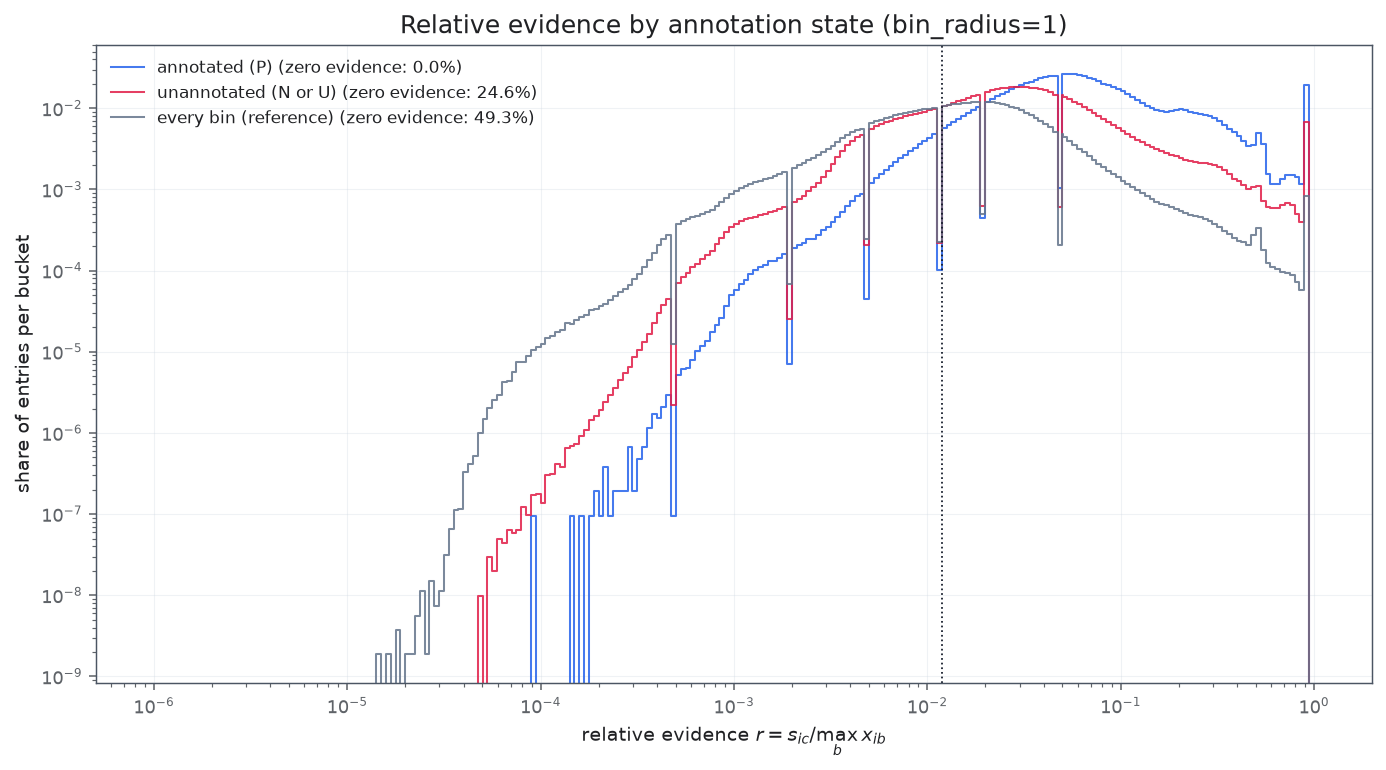

In [3]:
figure, axis = plt.subplots(figsize=(10.0, 5.6), dpi=theme.figure_dpi)
views.plot_evidence_distributions(
    statistics, bin_radius=CONFIGURED_BIN_RADIUS,
    candidate_thresholds=CONFIGURED_THRESHOLDS, ax=axis, theme=theme,
)
figure.tight_layout()
figure.savefig(ARTIFACT_DIR / "evidence_distributions.png")

distribution_frame = pd.DataFrame(
    thresholds.evidence_quantile_records(statistics, bin_radius=CONFIGURED_BIN_RADIUS)
)
distribution_frame.to_csv(ARTIFACT_DIR / "evidence_distribution_quantiles.csv", index=False)
display(distribution_frame)

## Agreement between annotation and local evidence, per ion

### Methodology

#### Theoretical

The pooled densities above can separate while individual ions do not, because pooling
mixes ions of very different intensity. The per-ion question is asked with a rank
statistic that involves no threshold at all:

$$
\mathrm{AUC}_c \;=\; \Pr\!\left(r_{ic} > r_{jc}\right) + \tfrac{1}{2}\Pr\!\left(r_{ic} = r_{jc}\right),
\qquad i \in A_c,\; j \in \bar{A}_c .
$$

It is the probability that a randomly chosen annotated pixel carries more signal at the
ion's bin than a randomly chosen unannotated one. $\mathrm{AUC}_c = 0.5$ means the
intensity at that bin carries no information about whether the ion is annotated there,
which invalidates *every* threshold for that ion rather than merely a badly chosen one:
whatever the cut, the negatives it produces for that ion are drawn at random with
respect to the ion's actual presence. Values below $0.5$ are stronger evidence still of
a problem — annotated pixels carrying *less* signal points at mapping or calibration,
not chemistry, and is followed up in `part_0_3`.

The statistic is deliberately threshold-free: it separates "is the evidence informative
for this ion at all" from "where should the cut go", and only the second question
depends on $\beta$.

#### Implementation

Computed from the two per-ion histograms rather than from pairs, which would be
$O(|A_c||\bar{A}_c|)$: with $u_k$ and $a_k$ the unannotated and annotated counts in
bucket $k$ ordered by increasing $r$,

$$
\mathrm{AUC}_c = \frac{1}{|A_c||\bar{A}_c|} \sum_k a_k \left(\sum_{j<k} u_j + \tfrac{1}{2} u_k\right).
$$

Entries sharing a bucket are counted as ties, which is the bucket-resolution reading of
the statistic and is conservative — it can only pull the value toward $0.5$, never away
from it. Ions with no annotated or no unannotated entry yield no value and are dropped.
Reported medians and quantiles are likewise bucket-resolution, exact to the grid
boundary containing them.

#### Figure descriptions

The x-axis is annotation prevalence on a logarithmic scale, the y-axis
$\mathrm{AUC}_c$; each point is one ion, so the figure shows all ions at once and not a
summary. The dashed horizontal line at $0.5$ is the no-information level. Vertical
spread at fixed prevalence is genuine between-ion variation in how well the evidence
tracks the annotation; a downward drift toward low prevalence would mean that rarely
annotated ions are also the ones whose evidence is least informative, which is the
combination that makes their operational negatives least trustworthy.

### Remarks

### Notes

2026-09-19 23:31:55,200 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.evidence.threshold_analysis:234 | Computed evidence separation for 508 ion(s) at bin_radius=1.


ions with a defined AUC: 508/508
median AUC: 0.7148
ions with AUC >= 0.5: 424/508
ions with AUC >= 0.6: 372/508
ions with AUC >= 0.7: 269/508
ions with AUC >= 0.8: 175/508
ions with AUC >= 0.9: 104/508
ions with AUC < 0.5 (annotated pixels carry LESS signal): 84


,class_name,mz,positive_entries,evidence_auc,median_relative_annotated,median_relative_unannotated
100,C17H32O4|-H,299.22278,14850.0,0.12139,0.01585,0.04467
144,C19H26N2O2|-H,313.19215,5527.0,0.14621,0.01585,0.04732
79,C16H28O6|-H,315.18131,15933.0,0.16092,0.01778,0.04217
167,C20H26O7|-H,377.16058,979.0,0.16566,0.00562,0.02000
183,C21H22N4O3|-H,377.16191,979.0,0.16584,0.00562,0.02000
91,C17H24N4O2|-H,315.18265,12282.0,0.16653,0.01778,0.04217
136,C18H36O3|-H,299.25917,13959.0,0.16843,0.01884,0.04467
270,C27H44O3|-H,415.32177,3126.0,0.16971,0.00841,0.03162
54,C14H28O5S|-H,307.15847,863.0,0.18847,0.00794,0.02818
501,C9H13N2O8P|-H,307.03368,418.0,0.20794,0.00794,0.02818


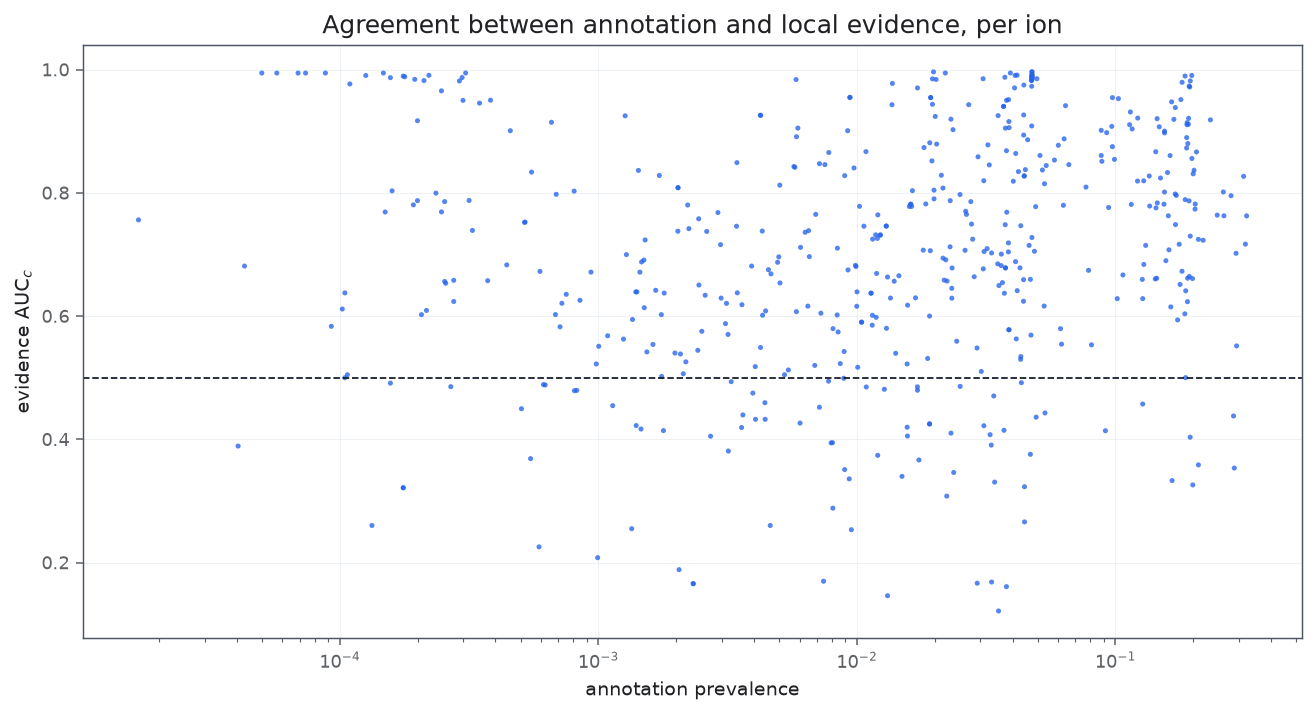

In [4]:
separation = pd.DataFrame(thresholds.evidence_separation_records(statistics, bin_radius=CONFIGURED_BIN_RADIUS))
separation.to_csv(ARTIFACT_DIR / "class_separation.csv", index=False)

figure, axis = plt.subplots(figsize=(9.5, 5.2), dpi=theme.figure_dpi)
views.plot_separation_summary(separation.to_dict("records"), ax=axis, theme=theme)
figure.tight_layout()
figure.savefig(ARTIFACT_DIR / "class_separation.png")

valid = separation.dropna(subset=["evidence_auc"])
print(f"ions with a defined AUC: {len(valid)}/{len(separation)}")
print(f"median AUC: {valid['evidence_auc'].median():.4f}")
for cut in (0.5, 0.6, 0.7, 0.8, 0.9):
    print(f"ions with AUC >= {cut}: {int((valid['evidence_auc'] >= cut).sum())}/{len(valid)}")
print(f"ions with AUC < 0.5 (annotated pixels carry LESS signal): {int((valid['evidence_auc'] < 0.5).sum())}")
display(valid.nsmallest(10, "evidence_auc")[
    ["class_name", "mz", "positive_entries", "evidence_auc",
     "median_relative_annotated", "median_relative_unannotated"]
].round(5))

## Threshold sweep: negative yield against positive contradiction

### Methodology

#### Theoretical

Both quantities are monotone in $\beta$, so there is no interior optimum to search for:
raising the threshold always produces more operational negatives and always contradicts
more annotated entries. The selection is therefore one-sided — fix a tolerance on the
contradiction rate and take the largest threshold that respects it:

$$
\beta^\star = \max\left\{\beta : \mathrm{contra}(\beta) \le \varepsilon\right\},
\qquad \varepsilon = 0.01 .
$$

The tolerance is a stated decision, not a derived quantity, and the sweep is reported in
full so the consequence of any other tolerance can be read off directly. The second
quantity to read at $\beta^\star$ is the negative-to-positive ratio $N/P$: it is the
class imbalance the P/N objectives will face, and it is what the `positive_weight_mode`
options in the campaign are configured to counteract.

#### Implementation

Both curves are exact counts, not estimates: the sweep runs over the histogram
boundaries themselves, and each value is a cumulative sum of bucket counts up to and
including the boundary. The grid carries 247 boundaries between $0$ and $1$, including
every candidate threshold, so no interpolation occurs anywhere. `recommend_threshold`
applies the selection rule above to the same records.

#### Figure descriptions

The x-axis is the relative threshold $\beta$ on a logarithmic scale. The solid red curve
is the share of *unannotated* entries the threshold converts into operational negatives;
the dashed blue curve is the share of *annotated* entries lying at or below the same
threshold. Both are shares of their own population, which is why they share one axis.
Dotted vertical lines mark the two thresholds the campaign currently proposes. Higher is
better for the red curve and worse for the blue one; the selected threshold is the
right-most point at which the blue curve is still below the stated tolerance.

### Remarks

- The two thresholds already in the configuration are far from equivalent: $\beta=0.005$
  contradicts 0.85 % of annotated entries, $\beta=0.01$ contradicts 3.46 % — a fourfold
  difference for a factor-of-two change in the threshold. The contradiction curve is much
  steeper than the yield curve in this region.
- Negative yield saturates slowly: even at $\beta=0.05$, 21 % of unannotated entries
  remain uncertain. There is no threshold at which the $U$ state disappears.

### Notes

2026-09-19 23:31:55,777 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.evidence.threshold_analysis:118 | Swept 248 relative threshold(s) at bin_radius=1.


2026-09-19 23:31:56,156 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.evidence.threshold_analysis:118 | Swept 6 relative threshold(s) at bin_radius=1.


,relative_threshold,negative_fraction_of_unannotated,uncertain_fraction_of_unannotated,negative_to_positive_ratio,positive_contradiction_rate
0,0.001,0.24789,0.75211,4.79907,0.00054
1,0.002,0.25361,0.74639,4.90987,0.00179
2,0.005,0.28708,0.71292,5.55776,0.00846
3,0.010,0.37269,0.62731,7.21512,0.03455
4,0.020,0.51258,0.48742,9.92339,0.11669
5,0.050,0.78666,0.21334,15.22944,0.41439


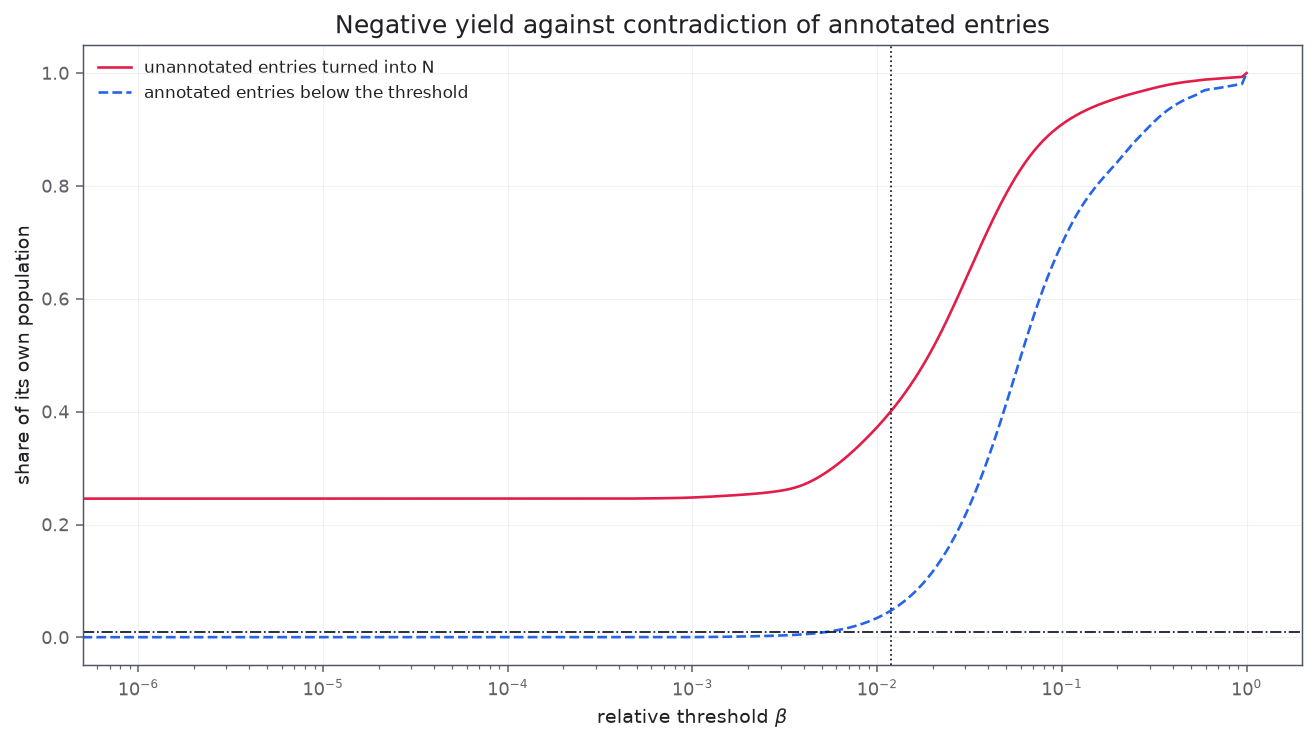

In [5]:
sweep = pd.DataFrame(thresholds.state_yield_records(statistics, bin_radius=CONFIGURED_BIN_RADIUS))
sweep.to_csv(ARTIFACT_DIR / "threshold_sweep.csv", index=False)

figure, axis = plt.subplots(figsize=(9.5, 5.4), dpi=theme.figure_dpi)
views.plot_threshold_sweep(sweep.to_dict("records"), candidate_thresholds=CONFIGURED_THRESHOLDS, ax=axis, theme=theme)
axis.axhline(CONTRADICTION_TOLERANCE, color=theme.baseline_color, linestyle="-.",
             linewidth=theme.reference_line_width)
figure.tight_layout()
figure.savefig(ARTIFACT_DIR / "threshold_sweep.png")

candidate_rows = pd.DataFrame(thresholds.state_yield_records(
    statistics, bin_radius=CONFIGURED_BIN_RADIUS, thresholds=CANDIDATE_THRESHOLDS
))
display(candidate_rows[[
    "relative_threshold", "negative_fraction_of_unannotated", "uncertain_fraction_of_unannotated",
    "negative_to_positive_ratio", "positive_contradiction_rate",
]].round(5))
candidate_rows.to_csv(ARTIFACT_DIR / "candidate_thresholds.csv", index=False)

In [6]:
recommendation = thresholds.recommend_threshold(
    statistics, bin_radius=CONFIGURED_BIN_RADIUS, maximum_contradiction_rate=CONTRADICTION_TOLERANCE,
)
tolerance_rows = []
for tolerance in (0.001, 0.005, 0.01, 0.02, 0.05, 0.10):
    selected = thresholds.recommend_threshold(
        statistics, bin_radius=CONFIGURED_BIN_RADIUS, maximum_contradiction_rate=tolerance,
    )
    tolerance_rows.append({
        "contradiction_tolerance": tolerance,
        "selected_relative_threshold": selected["relative_threshold"],
        "realized_contradiction_rate": selected["positive_contradiction_rate"],
        "negative_fraction_of_unannotated": selected["negative_fraction_of_unannotated"],
        "negative_to_positive_ratio": selected["negative_to_positive_ratio"],
    })
tolerance_frame = pd.DataFrame(tolerance_rows)
tolerance_frame.to_csv(ARTIFACT_DIR / "threshold_recommendation.csv", index=False)
display(tolerance_frame.round(5))
print(f"selection at tolerance {CONTRADICTION_TOLERANCE}: relative_threshold="
      f"{recommendation['relative_threshold']:.6g}")

2026-09-19 23:31:56,538 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.evidence.threshold_analysis:118 | Swept 248 relative threshold(s) at bin_radius=1.


2026-09-19 23:31:56,539 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.evidence.threshold_analysis:472 | Selected relative_threshold=0.005308844442 at bin_radius=1 (contradiction=0.0096, negative yield=0.2925).


2026-09-19 23:31:56,550 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.evidence.threshold_analysis:118 | Swept 248 relative threshold(s) at bin_radius=1.


2026-09-19 23:31:56,551 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.evidence.threshold_analysis:472 | Selected relative_threshold=0.001412537545 at bin_radius=1 (contradiction=0.0010, negative yield=0.2504).


2026-09-19 23:31:56,561 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.evidence.threshold_analysis:118 | Swept 248 relative threshold(s) at bin_radius=1.


...

2026-09-19 23:31:56,608 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.evidence.threshold_analysis:472 | Selected relative_threshold=0.0119 at bin_radius=1 (contradiction=0.0478, negative yield=0.4012).


2026-09-19 23:31:56,618 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.evidence.threshold_analysis:118 | Swept 248 relative threshold(s) at bin_radius=1.


2026-09-19 23:31:56,619 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.evidence.threshold_analysis:472 | Selected relative_threshold=0.0177827941 at bin_radius=1 (contradiction=0.0962, negative yield=0.4831).


,contradiction_tolerance,selected_relative_threshold,realized_contradiction_rate,negative_fraction_of_unannotated,negative_to_positive_ratio
0,0.001,0.00141,0.00098,0.25035,4.84677
1,0.005,0.00376,0.00486,0.26745,5.17781
2,0.010,0.00531,0.00956,0.29255,5.66364
3,0.020,0.00750,0.01960,0.33166,6.42076
4,0.050,0.01190,0.04776,0.40116,7.76639
5,0.100,0.01778,0.09624,0.48307,9.35203


selection at tolerance 0.01: relative_threshold=0.00530884


## Per-ion state composition and evidence regimes

### Methodology

#### Theoretical

A pooled negative yield does not say which ions the negatives come from, and two very
different situations produce the same pooled number. An ion may be *rare* — annotated in
few pixels, but with intensity at its bin nearly everywhere, so its unannotated entries
stay $U$ and it contributes almost nothing to a P/N objective. Or it may be
*undetectable* — its bin essentially empty across the image, so nearly every unannotated
entry becomes $N$ and the class is trained on negatives that encode the absence of
measurement rather than the absence of the molecule. The distinction matters for the
campaign because the `per_class_sqrt_negative_to_positive` weighting computes its
multiplier from exactly these per-class $N$ and $P$ counts, and an undetectable class
supplies a large, uninformative $N$.

Ions are assigned a regime at the selected threshold: `undetectable` when at least 95 %
of their unannotated entries become negatives, `rare` when prevalence is below 1 % while
that share stays lower, and `common` otherwise. Both cut-offs are stated conventions;
the underlying quantities are reported per ion so any other cut can be applied to the
persisted table.

#### Implementation

Per-ion cumulative counts at the selected threshold, from the same histograms as the
pooled sweep and therefore equally exact. Prevalence is entry-weighted over available
labels, matching `part_0_1`.

#### Figure descriptions

The x-axis is annotation prevalence on a logarithmic scale and the y-axis the share of
that ion's unannotated entries the selected threshold turns into operational negatives;
each point is one ion at one fixed threshold. Colour marks the assigned regime and is
redundant with position by construction — it is a reading aid, not extra information.
The upper-left region holds ions that are both rarely annotated and almost entirely
negative: classes a P/N objective sees as essentially pure negatives.

### Remarks

- No ion reaches the 95 % negative-fraction cut-off at the selected threshold, so the
  `undetectable` regime is empty here: 310 ions are `common` and 198 `rare`. The regime
  only appears at $\beta = 0.05$, where 119 ions cross it.
- The `rare` ions carry a median negative-to-positive ratio of 151 against 3.9 for the
  `common` ones. Per-class weighting under
  `per_class_sqrt_negative_to_positive` would give them a multiplier around
  $\sqrt{151} \approx 12$, above the configured `max_positive_weight: 10.0`, so the cap
  binds for a large part of the class set rather than for outliers.

### Notes

2026-09-19 23:31:56,636 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.evidence.class_population_analysis:139 | Ion regimes at relative_threshold=0.0119: {'rare': 198, 'common': 310}.


,ions,median_prevalence,median_negative_fraction,median_negative_to_positive
regime,,,,
common,310,0.0432,0.4040,6.7386
rare,198,0.0018,0.4601,233.2516


,median_negative_fraction,ions_above_95_percent_negative,median_negative_to_positive
relative_threshold,,,
0.001,0.2002,0,11.1954
0.002,0.2136,0,11.9723
0.005,0.2624,0,13.4840
0.010,0.4054,0,17.5831
0.020,0.5777,0,24.4693
0.050,0.8618,119,38.9270


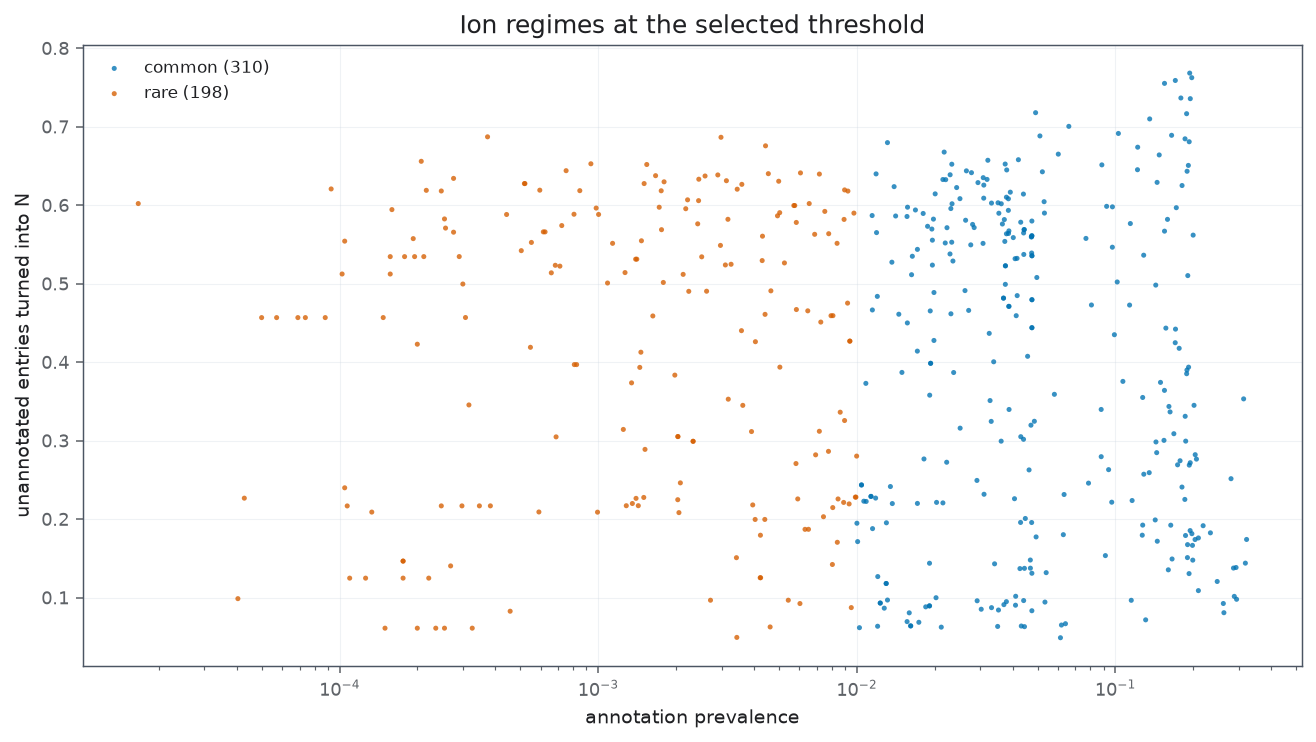

In [7]:
# The campaign configuration, not the recommendation from this diagnostic, defines
# the local class regimes consumed by the downstream prediction notebook.
SELECTED_THRESHOLD = float(settings["evidence"]["relative_threshold"])

regimes = pd.DataFrame(population.class_regime_records(
    statistics, bin_radius=CONFIGURED_BIN_RADIUS, relative_threshold=SELECTED_THRESHOLD,
))
regimes.to_csv(ARTIFACT_DIR / "class_regimes.csv", index=False)

figure, axis = plt.subplots(figsize=(9.5, 5.4), dpi=theme.figure_dpi)
views.plot_class_regimes(regimes.to_dict("records"), ax=axis, theme=theme)
figure.tight_layout()
figure.savefig(ARTIFACT_DIR / "class_regimes.png")

display(regimes.groupby("regime").agg(
    ions=("class_name", "size"),
    median_prevalence=("prevalence", "median"),
    median_negative_fraction=("negative_fraction_of_unannotated", "median"),
    median_negative_to_positive=("negative_to_positive_ratio", "median"),
).round(4))

class_states = pd.DataFrame(thresholds.class_state_records(
    statistics, bin_radius=CONFIGURED_BIN_RADIUS, thresholds=CANDIDATE_THRESHOLDS,
))
class_states.to_csv(ARTIFACT_DIR / "class_states.csv", index=False)
display(
    class_states.groupby("relative_threshold").agg(
        median_negative_fraction=("negative_fraction_of_unannotated", "median"),
        ions_above_95_percent_negative=("negative_fraction_of_unannotated", lambda values: int((values >= 0.95).sum())),
        median_negative_to_positive=("negative_to_positive_ratio", "median"),
    ).round(4)
)

## Results / Summary

### LLM

**Recommendation.** Set `relative_threshold: 0.005` and keep `bin_radius: 1`. The
selection rule — largest threshold whose positive contradiction rate stays at or below
1 % — returns $\beta^\star = 0.00531$ at a realized contradiction rate of 0.96 %, and
0.005 is the nearest value already present in the configuration, differing from the
selected one by 6 %. **Drop `relative_threshold: 0.01` from the grid**: it contradicts
3.46 % of annotated entries, four times the tolerance, for a yield gain from 28.7 % to
37.3 %. If the grid must keep two values, $0.002$ (yield 25.4 %, contradiction 0.18 %) is
the defensible second point, not $0.01$.

**Observed results.**

- At $\beta = 0.005$, bin radius 1: 28.7 % of unannotated entries become operational
  negatives, 71.3 % stay uncertain, and the negative-to-positive ratio is 5.6.
- The contradiction rate rises much faster than the yield: doubling the threshold from
  0.005 to 0.01 adds 8.6 points of yield and quadruples the contradiction rate.
- Reported for other tolerances: 0.1 % → $\beta = 0.0014$ (yield 25.0 %); 5 % →
  $\beta = 0.0119$ (yield 40.1 %); 10 % → $\beta = 0.0178$ (yield 48.3 %).
- Evidence and annotation agree at the ion level for most ions: median
  $\mathrm{AUC}_c = 0.715$, with 269 of 508 ions above 0.7.

**Evidence of a problem.** 84 of 508 ions have $\mathrm{AUC}_c < 0.5$, meaning their
annotated pixels carry *less* signal at their own bin than their unannotated ones. For
those ions the rule's negatives are worse than uninformative — they are anti-correlated
with the annotation. The effect is large for the worst cases and cannot be explained by
the threshold, which does not enter the statistic. `part_0_3` tests two candidate
explanations.

**Interpretation, and what this result is not.** The contradiction rate is an optimistic
bound, not an error rate: annotated entries are by construction ones METASPACE could
detect, so entries with no annotation plausibly fail the threshold more often than they
do, not less. The selection is therefore conservative *only if* that bias is the dominant
one. The pooled sweep also weights acquisitions by their entry count, and `part_0_1`
showed those differ by two orders of magnitude in annotation load; `part_0_3` shows this
matters a great deal and qualifies the number recommended here. Finally, `part_0_1`
established that 328 of 508 ion columns share a bin, so the per-ion statistics above are
shared within a bin rather than independently measured — the AUC distribution has fewer
effective degrees of freedom than 508.

### Person